In [1]:
from resources.imports import *

from resources.lattices import Geometry, effProperties
from resources.MLdata import DATA, load_data, UTprops, FTprops, prep_MULTIdata, remove_outliers, save_MLdata, save_MULTIdata, \
                             plot_sampling, get_stats, plot_frequency, plot_properties, plot_curve

In [2]:
### Global Inputs

mode = ("compare", "Target-xs")

DAT = DATA(path=1, 
        path_add="",
        load=False,
        load_split=False,
        split_frac=0.8,
        save_split=False,
        LAT="FCC",
        dis="disNodes", 
        dN=0.2,
        mechMode="MULTI")

if mode is not None:
    if mode[0].lower() == "compare":
        DATc = DATA(path=1, 
                    path_add=mode[1],
                    load=DAT.load,
                    LAT=DAT.LAT, 
                    dis=DAT.dis, 
                    dN=DAT.dN,
                    mechMode=DAT.mechMode)

if DAT.LAT.lower() == "fcc":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "kagome":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "hex":
    manual_outliersUT = None
    manual_outliersFT = [566]
elif DAT.LAT.lower() == "tri":
    manual_outliersUT = None
    manual_outliersFT = None

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\lattices.py:672: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


# Load Data

In [3]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_INcsv  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
        DAT.UT_OUTcsv = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
        DAT.UT_INcsv_f = None
        if DAT.freq:
            DAT.UT_INcsv_f = DAT.PATH + f'Ductile-{DAT.dis}-INf.csv'

    if DAT.FTmechTest:
        DAT.FT_INcsv  = DAT.PATH + f'Fracture-{DAT.dis}-IN.csv'
        DAT.FT_OUTcsv = DAT.PATH + f'Fracture-{DAT.dis}-OUT.csv'
        DAT.FT_INcsv_f = None
        if DAT.freq:
            DAT.FT_INcsv_f = DAT.PATH + f'Fracture-{DAT.dis}-INf.csv'

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_INcsv  = DATc.PATH + f'Ductile-{DATc.dis}-IN.csv'
            DATc.UT_OUTcsv = DATc.PATH + f'Ductile-{DATc.dis}-OUT.csv'
            DATc.UT_INcsv_f = None
            if DATc.freq:
                DATc.UT_INcsv_f = DATc.PATH + f'Ductile-{DATc.dis}-INf.csv'

        if DATc.FTmechTest:
            DATc.FT_INcsv  = DATc.PATH + f'Fracture-{DATc.dis}-IN.csv'
            DATc.FT_OUTcsv = DATc.PATH + f'Fracture-{DATc.dis}-OUT.csv'
            DATc.FT_INcsv_f = None
            if DATc.freq:
                DATc.FT_INcsv_f = DATc.PATH + f'Fracture-{DATc.dis}-INf.csv'

In [4]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_INf_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_df = load_data(DAT.UT_INcsv, DAT.UT_OUTcsv, DAT.UT_INcsv_f)

    if DAT.FTmechTest:
        DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_INf_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_props_df = load_data(DAT.FT_INcsv, DAT.FT_OUTcsv, DAT.FT_INcsv_f)

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_INf_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_props_df = load_data(DATc.UT_INcsv, DATc.UT_OUTcsv, DATc.UT_INcsv_f)

        if DATc.FTmechTest:
            DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_INf_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_props_df = load_data(DATc.FT_INcsv, DATc.FT_OUTcsv, DATc.FT_INcsv_f)

# Geometry

In [5]:
if DAT.load is not True:
    DAT.geom.FTcalc()

# Prep Data

In [6]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_props_r_df = UTprops(DAT.UT_OUT_df)
        DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_df, DAT.UT_INf_df = remove_outliers(DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_r_df, DAT.UT_INf_df, manual=manual_outliersUT)
        save_MLdata(DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_props_df, DAT.PATH, "UT", DAT.dis, DAT.UT_INf_df)

    if DAT.FTmechTest:
        DAT.FT_props_r_df = FTprops(DAT.FT_OUT_df, DAT.geom, DAT.E_eff_pe)
        DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_props_df, DAT.FT_INf_df = remove_outliers(DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_props_r_df, DAT.FT_INf_df, manual=manual_outliersFT)
        save_MLdata(DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_props_df, DAT.PATH, "FT", DAT.dis, DAT.FT_INf_df)

    if DAT.UTmechTest and DAT.FTmechTest:
        DAT.common_props_df, DAT.common_IN_dfs, DAT.common_OUT_dfs, DAT.common_dIN_dfs, DAT.common_dOUT_dfs, DAT.common_INf_dfs = prep_MULTIdata([DAT.UT_IN_df, DAT.FT_IN_df], [DAT.UT_OUT_df, DAT.FT_OUT_df], [DAT.UT_dIN_df, DAT.FT_dIN_df] , [DAT.UT_dOUT_df, DAT.FT_dOUT_df], [DAT.UT_props_df, DAT.FT_props_df], [DAT.UT_INf_df, DAT.FT_INf_df], DAT.E_eff_pe)
        save_MULTIdata(DAT.common_IN_dfs, DAT.common_OUT_dfs, DAT.common_props_df, DAT.PATH, DAT.dis, DAT.common_INf_dfs)

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_props_r_df = UTprops(DATc.UT_OUT_df)
            DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_props_df, DATc.UT_INf_df = remove_outliers(DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_props_r_df, DATc.UT_INf_df, manual=manual_outliersUT)
            save_MLdata(DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_props_df, DATc.PATH, "UT", DATc.dis, DATc.UT_INf_df)
        
        if DATc.FTmechTest:
            DATc.FT_props_r_df = FTprops(DATc.FT_OUT_df, DATc.geom, DATc.E_eff_pe)
            DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_props_df, DATc.FT_INf_df = remove_outliers(DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_props_r_df, DATc.FT_INf_df, manual=manual_outliersFT)
            save_MLdata(DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_props_df, DATc.PATH, "FT", DATc.dis, DATc.FT_INf_df)

        if DATc.UTmechTest and DATc.FTmechTest:
            DATc.common_props_df, DATc.common_IN_dfs, DATc.common_OUT_dfs, DATc.common_dIN_dfs, DATc.common_dOUT_dfs, DATc.common_INf_dfs = prep_MULTIdata([DATc.UT_IN_df, DATc.FT_IN_df], [DATc.UT_OUT_df, DATc.FT_OUT_df], [DATc.UT_dIN_df, DATc.FT_dIN_df] , [DATc.UT_dOUT_df, DATc.FT_dOUT_df], [DATc.UT_props_df, DATc.FT_props_df], [DATc.UT_INf_df, DATc.FT_INf_df], DATc.E_eff_pe)
            save_MULTIdata(DATc.common_IN_dfs, DATc.common_OUT_dfs, DATc.common_props_df, DATc.PATH, DATc.dis, DATc.common_INf_dfs)

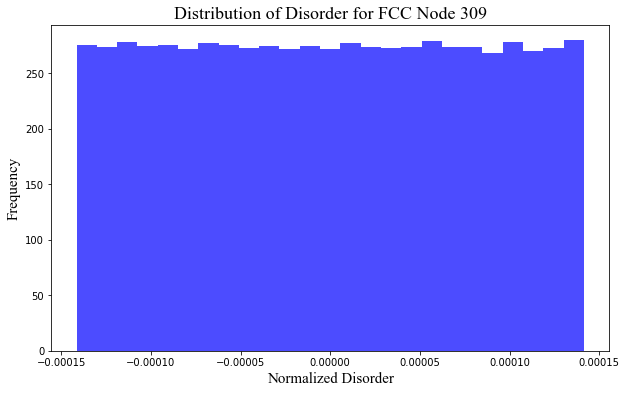

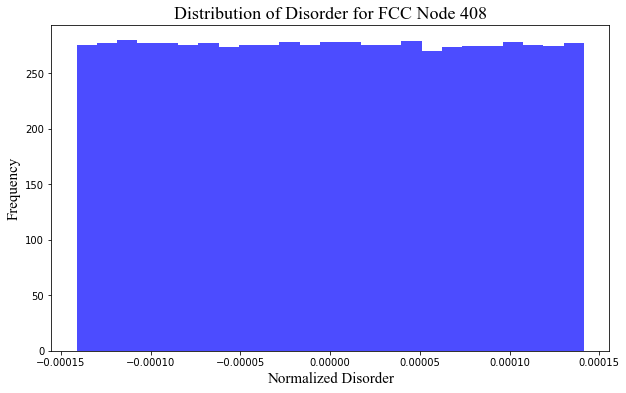

In [7]:
if DAT.UTmechTest:
    plot_sampling(DAT.UT_dIN_df, DAT.LAT, DAT.geom.l, indx=None, num=1, by="Node")
if DAT.FTmechTest:
    plot_sampling(DAT.FT_dIN_df, DAT.LAT, DAT.geom.l, indx=None, num=1, by="Node")

In [8]:
if DAT.UTmechTest:
    DAT.UT_stats, DAT.UT_nSims = get_stats(DAT.UT_props_df)
    print("FINAL UT SIMULATION COUNT:", len(DAT.UT_OUT_df)-1)
    print(f"{pd.concat([DAT.UT_stats, DAT.UT_nSims])}\n\n")

if DAT.FTmechTest:
    DAT.FT_stats, DAT.FT_nSims = get_stats(DAT.FT_props_df)
    print("FINAL FT SIMULATION COUNT:", len(DAT.FT_OUT_df)-1)
    print(f"{pd.concat([DAT.FT_stats, DAT.FT_nSims])}\n\n")

if DAT.UTmechTest and DAT.FTmechTest:
    DAT.common_stats, DAT.common_nSims = get_stats(DAT.common_props_df)
    print("FINAL COMMON SIMULATION COUNT:", len(DAT.common_props_df)-1)
    print(f"{pd.concat([DAT.common_stats, DAT.common_nSims])}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if DATc.UTmechTest:
        DATc.UT_stats, DATc.UT_nSims = get_stats(DATc.UT_props_df)
        print("FINAL UT SIMULATION COUNT:", len(DATc.UT_OUT_df)-1)
        print(f"{pd.concat([DATc.UT_stats, DATc.UT_nSims])}\n\n")

    if DATc.FTmechTest:
        DATc.FT_stats, DATc.FT_nSims = get_stats(DATc.FT_props_df)
        print("FINAL FT SIMULATION COUNT:", len(DATc.FT_OUT_df)-1)
        print(f"{pd.concat([DATc.FT_stats, DATc.FT_nSims])}\n\n")

    if DATc.UTmechTest and DATc.FTmechTest:
        DATc.common_stats, DATc.common_nSims = get_stats(DATc.common_props_df)
        print("FINAL COMMON SIMULATION COUNT:", len(DATc.common_props_df)-1)
        print(f"{pd.concat([DATc.common_stats, DATc.common_nSims])}\n\n")

FINAL UT SIMULATION COUNT: 6865
           Ductility     Strength    Stiffness          WoF
Mean        0.032389    60.324262  7243.207114     1.481356
Std         0.004029     0.682580    16.856961     0.147112
\%d Mean    0.286065    -0.050157    -0.019150     0.031007
\%d Std    -0.840039    -0.989252    -0.997717    -0.897611
Max        14.000000  1464.000000  2033.000000  5671.000000
Min       944.000000  6213.000000   137.000000  4661.000000


FINAL FT SIMULATION COUNT: 6907
                 K_JIC         K_IC         Force  Displacement
Mean      20326.458787   768.389478  80767.175926      0.006277
Std        3575.032056    39.426616   4144.221763      0.000867
\%d Mean      0.004240    -0.106084     -0.106084      0.019566
\%d Std      -0.823374    -0.954133     -0.954133     -0.859113
Max         461.000000   286.000000    286.000000    461.000000
Min         934.000000  2949.000000   2949.000000    447.000000


FINAL COMMON SIMULATION COUNT: 6773
           Ductility     Str

In [9]:
if DAT.UTmechTest:
    print(f"{(DAT.UT_props_df.loc[DAT.UT_nSims['Ductility'].loc['Max']]-DAT.UT_props_df.iloc[0])/DAT.UT_props_df.iloc[0]}\n\n")

if DAT.FTmechTest:
    print(f"{(DAT.FT_props_df.loc[DAT.FT_nSims['K_JIC'].loc['Max']]-DAT.FT_props_df.iloc[0])/DAT.FT_props_df.iloc[0]}\n\n")

if DAT.UTmechTest and DAT.FTmechTest:
    print(f"{(DAT.common_props_df.loc[DAT.common_nSims['FCL'].loc['Max']]-DAT.common_props_df.iloc[0])/DAT.common_props_df.iloc[0]}\n\n")
    print(f"{(DAT.common_props_df.loc[DAT.common_nSims['Multi'].loc['Max']]-DAT.common_props_df.iloc[0])/DAT.common_props_df.iloc[0]}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if DATc.UTmechTest:
        print(f"{(DATc.UT_props_df.loc[DATc.UT_nSims['Ductility'].loc['Max']]-DATc.UT_props_df.iloc[0])/DATc.UT_props_df.iloc[0]}\n\n")

    if DATc.FTmechTest:
        print(f"{(DATc.FT_props_df.loc[DATc.FT_nSims['K_JIC'].loc['Max']]-DATc.FT_props_df.iloc[0])/DATc.FT_props_df.iloc[0]}\n\n")

    if DATc.UTmechTest and DATc.FTmechTest:
        print(f"{(DATc.common_props_df.loc[DATc.common_nSims['FCL'].loc['Max']]-DATc.common_props_df.iloc[0])/DATc.common_props_df.iloc[0]}\n\n")
        print(f"{(DATc.common_props_df.loc[DATc.common_nSims['Multi'].loc['Max']]-DATc.common_props_df.iloc[0])/DATc.common_props_df.iloc[0]}\n\n")

Ductility    0.784178
Strength    -0.046678
Stiffness   -0.015628
WoF          0.273232
dtype: float64


K_JIC           0.556040
K_IC            0.017039
Force           0.017039
Displacement    0.456756
dtype: float64


Ductility       0.083097
Strength       -0.065317
Stiffness      -0.016362
WoF            -0.204041
K_JIC           0.554991
K_IC           -0.013741
Force          -0.013741
Displacement    0.456756
Multi           0.355699
FCL             2.037841
dtype: float64


Ductility       0.784178
Strength       -0.042204
Stiffness      -0.019074
WoF             0.196025
K_JIC           0.401138
K_IC           -0.000941
Force          -0.000941
Displacement    0.333309
Multi           0.726722
FCL             0.641427
dtype: float64



=============== COMPARISON DATA ===============

Ductility    0.831839
Strength    -0.019262
Stiffness    0.001929
WoF          0.209630
dtype: float64


K_JIC           0.129913
K_IC            0.019635
Force           0.019635
Displacement  

# Plot Distribution & Identify Max, Min Simulations

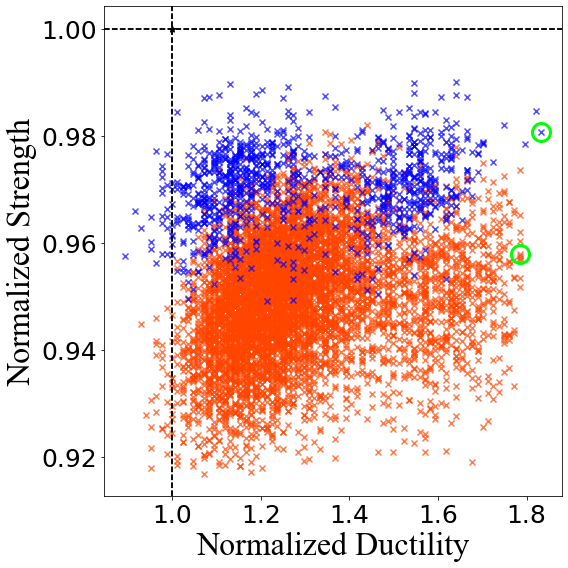

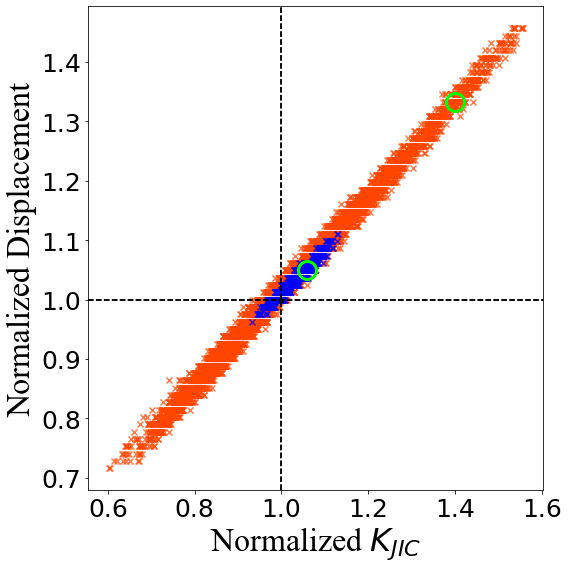

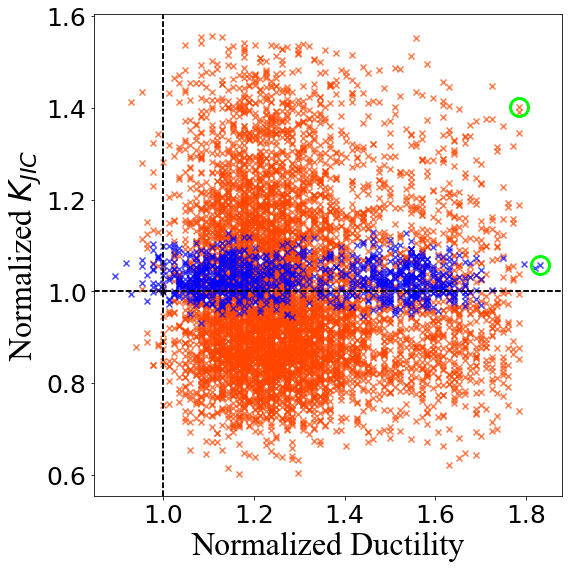

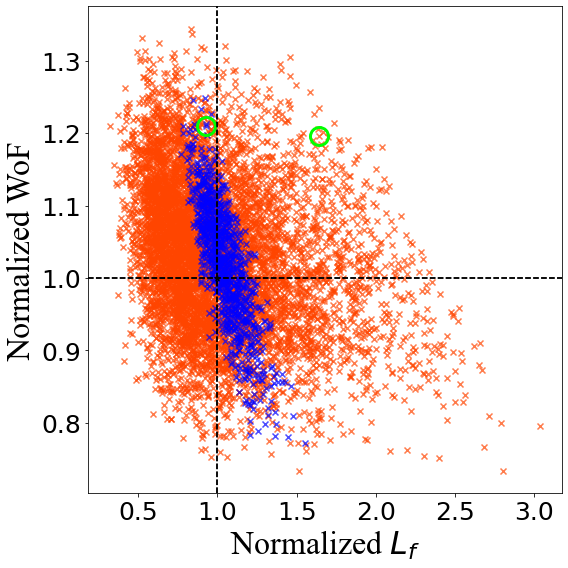

In [10]:
plot_allProps = True
plot_freq = False
plot_ONLY_freq = False

if plot_allProps:
    if DAT.UTmechTest:  
        fig, ax = plot_properties(DAT.UT_props_df["Ductility"], DAT.UT_props_df["Strength"], "UT", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.UT_props_df["Ductility"], DATc.UT_props_df["Strength"], "UT", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
    
    if DAT.FTmechTest:  
        fig, ax = plot_properties(DAT.FT_props_df["K_JIC"], DAT.FT_props_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.FT_props_df["K_JIC"], DATc.FT_props_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
   
    if DAT.UTmechTest and DAT.FTmechTest:   
        fig, ax = plot_properties(DAT.common_props_df["Ductility"], DAT.common_props_df["K_JIC"], "MULTI", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_props_df["Ductility"], DATc.common_props_df["K_JIC"], "MULTI", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
            
        fig, ax = plot_properties(DAT.common_props_df["FCL"], DAT.common_props_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_props_df["FCL"], DATc.common_props_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)

if plot_ONLY_freq and DAT.load is not True:
    if DAT.UTmechTest:
        plot_frequency(DAT.UT_props_r_df["Ductility"], DAT.UT_props_df["Ductility"], "UT", bins=30)
    if DAT.FTmechTest:
        plot_frequency(DAT.FT_props_r_df["K_JIC"], DAT.FT_props_df["K_JIC"], "FT", bins=30)
    if DAT.UTmechTest and DAT.FTmechTest:
        plot_frequency(DAT.common_props_df["FCL"], DAT.common_props_df["FCL"], "FCL", bins=30)

# Plots UT and FT Curves

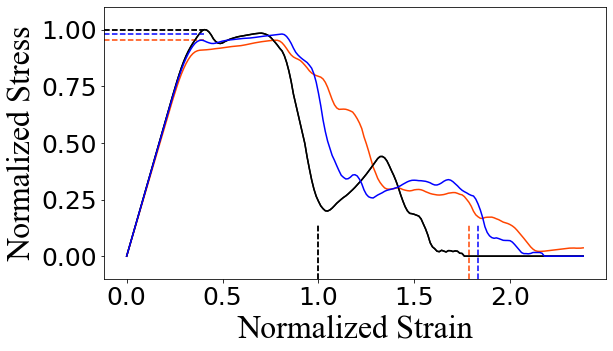

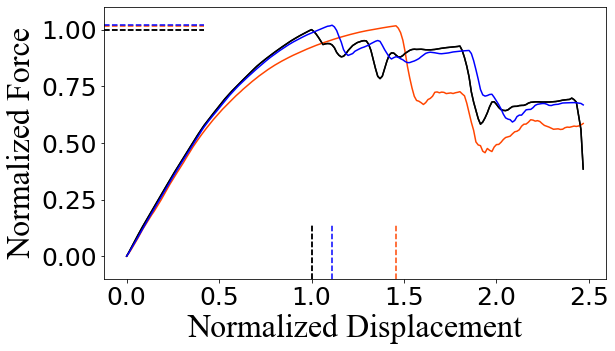

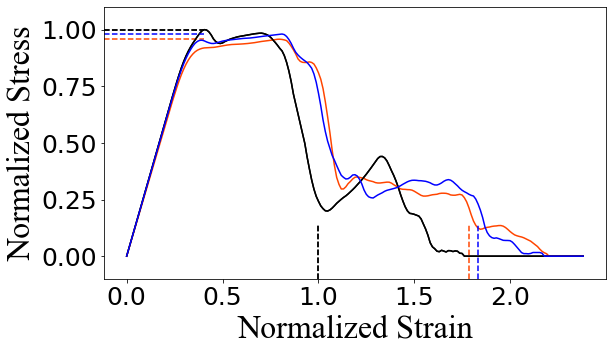

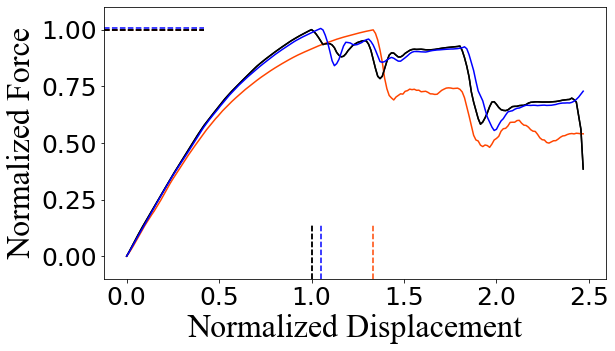

In [11]:
idx = None
q   = "all"
if DAT.UTmechTest:
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, "ut", idx=[DAT.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, "ut", idx=[DATc.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if DAT.FTmechTest:
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, "ft", idx=[DAT.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, "ft", idx=[DATc.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if DAT.UTmechTest and DAT.FTmechTest:
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, "ut", idx=[DAT.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, "ut", idx=[DATc.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
        
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, "ft", idx=[DAT.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, "ft", idx=[DATc.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=(fig2, ax1))